In [15]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Lectura de parámetros desde config.xlsx
config = pd.read_excel(os.path.join(BASE_PATH, "NOTEBOOKS", "config.xlsx"), sheet_name="config", index_col="parameter")["value"]
min_k_clusters = int(config["min_k_clusters"])
max_k_clusters = int(config["max_k_clusters"])
k_final = int(config["k_final"])

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

print(f"Rango de clusters: {min_k_clusters} a {max_k_clusters}")
print(f"k_final: {k_final}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline
Rango de clusters: 2 a 8
k_final: 4


# CARGA DE DATOS

In [16]:
base_path = os.path.join(BASE_PATH, "DATA", "PROCESSED")

df_oleaje = pd.read_csv(os.path.join(base_path, "df_wave.csv"))
df_features = pd.read_csv(os.path.join(base_path, "df_features.csv"))

df = pd.merge(
    df_oleaje,
    df_features,
    on="window_id",
    how="inner"
)

df_oleaje.head()

,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vz,mean_O2,...,flux_smooth,flag_outlier_global,flag_outlier_window,flag_flux_positivo,flag_vz_baja,Oleaje,Mod_orbital,STD_orbital,hour_int,Oleaje_SIMAR
0,0,13.12,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-0.000940,219.341074,...,-6.351335,False,False,False,False,9.664,0.015203,0.009969,13,1.87
1,1,13.37,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-0.001864,220.214211,...,-6.745481,False,False,False,False,9.876,0.015946,0.010475,13,1.87
2,2,13.62,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-0.001838,220.537457,...,-6.619435,False,False,False,False,9.004,0.013689,0.008438,13,1.87
3,3,13.87,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.001537,220.398051,...,-6.799723,False,False,False,False,8.556,0.012808,0.008059,13,1.87
4,4,14.12,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.001444,220.429227,...,-6.911006,False,False,False,False,9.500,0.013456,0.007926,14,1.86


# IMPLEMENTACIÓN K-MEANS

## Algoritmo K-Means

K-Means es un algoritmo de clustering no supervisado que particiona las observaciones en $k$ grupos, minimizando la suma de distancias euclídeas al cuadrado entre cada punto y el centroide de su cluster asignado.

**Pasos del algoritmo:**
1. Se inicializan $k$ centroides aleatoriamente (se usa `n_init=20` para reducir la sensibilidad a la inicialización).
2. Cada observación se asigna al centroide más cercano.
3. Los centroides se recalculan como la media de los puntos asignados.
4. Se repiten los pasos 2–3 hasta convergencia.

## Preprocesamiento de variables

Antes de aplicar K-Means, las variables de entrada se preprocesan:
- **Imputación**: los valores faltantes se sustituyen por la mediana de cada variable (`SimpleImputer(strategy="median")`), evitando la influencia de outliers.
- **Estandarización**: se aplica `StandardScaler` para centrar y escalar cada variable a media 0 y desviación típica 1, garantizando que todas contribuyan equitativamente a la distancia euclídea.

## Métricas de evaluación del clustering

- **Método del codo (Elbow)**: se representa la inercia (suma de distancias intra-cluster al cuadrado) frente a $k$. El "codo" indica el punto a partir del cual añadir más clusters no reduce significativamente la inercia.
- **Coeficiente de Silhouette**: mide la cohesión y separación de los clusters. Varía entre −1 y 1; valores altos indican clusters bien definidos y separados.

## Criterio de selección

La selección de la combinación óptima (fuente de oleaje × número de clusters) se basa en tres criterios simultáneos:
1. **Significancia estadística**: el contraste sobre `flux_O2` entre grupos debe ser significativo ($p < 0{,}05$).
2. **Coherencia física**: la diferencia de mediana del flujo ($\Delta$ mediana) debe ser negativa, reflejando que más oleaje se asocia a mayor consumo de oxígeno.
3. **Calidad del clustering**: entre las combinaciones que cumplen los dos criterios anteriores, se elige la de mayor coeficiente de silhouette.

## Reordenación de clusters

Dado que K-Means asigna etiquetas de cluster de forma arbitraria, tras cada ajuste se reordenan los clusters por la media ascendente de la variable de oleaje. Así, el cluster 0 siempre corresponde a "poco oleaje" y el cluster más alto a "mucho oleaje", facilitando la interpretación física de los resultados.

# VARIABLES

In [17]:
# Variables comunes de presión
pres_features = [
    "pres__mean",
    "pres__standard_deviation",
    "pres__median",
]

# Definición de escenarios
escenarios = {
    "Wiberg": {
        "features": ["Oleaje", "Mod_orbital", "STD_orbital"] + pres_features,
        "col_oleaje": "Oleaje",
    },
    "SIMAR": {
        "features": ["Oleaje_SIMAR"] + pres_features,
        "col_oleaje": "Oleaje_SIMAR",
    },
}

for nombre, esc in escenarios.items():
    print(f"{nombre}: {esc['features']}")

Wiberg: ['Oleaje', 'Mod_orbital', 'STD_orbital', 'pres__mean', 'pres__standard_deviation', 'pres__median']
SIMAR: ['Oleaje_SIMAR', 'pres__mean', 'pres__standard_deviation', 'pres__median']


In [18]:
# Preprocesado para cada escenario
X_scaled_dict = {}

for nombre, esc in escenarios.items():
    X = df[esc["features"]].copy()
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_scaled_dict[nombre] = scaler.fit_transform(imputer.fit_transform(X))
    print(f"{nombre}: {X_scaled_dict[nombre].shape}")

Wiberg: (660, 6)
SIMAR: (660, 4)


# SELECCIÓN DE FUENTE DE OLEAJE Y NÚMERO DE CLUSTERS

Antes de aplicar la clasificación definitiva, se evalúan todas las combinaciones escenario × k para seleccionar la fuente de oleaje y el número de clusters óptimos.

Criterios de evaluación:
- **Silhouette**: calidad interna del clustering
- **Test sobre flux_O2**: Mann-Whitney U (k=2) o Kruskal-Wallis (k>2)

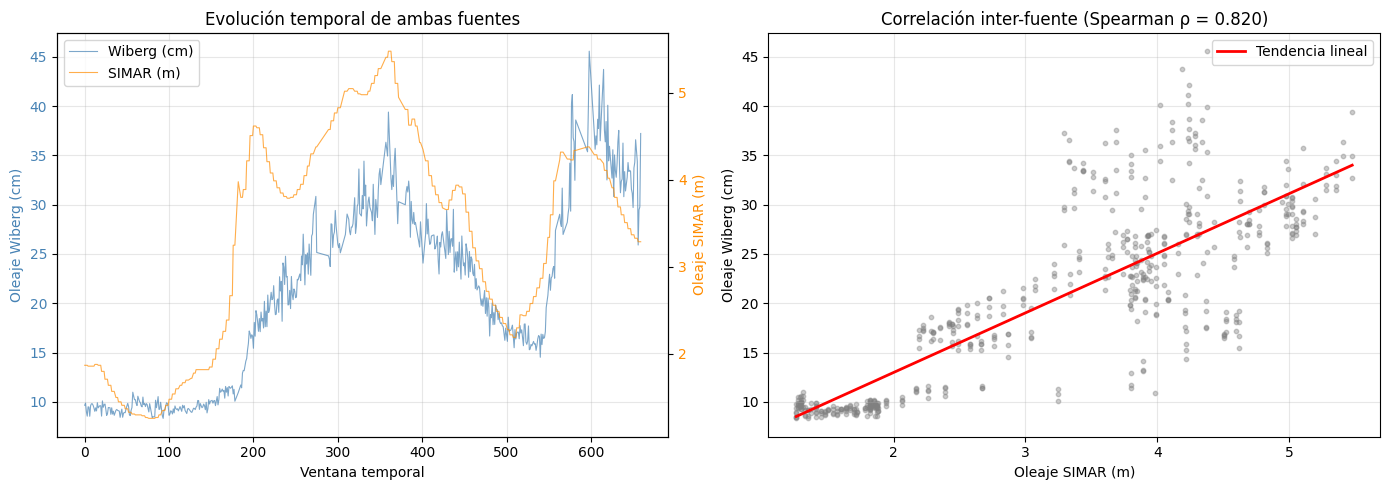

In [ ]:
# ============================================================
# FIGURA: Evolución temporal y correlación entre fuentes
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: serie temporal de ambas fuentes (doble eje Y por las unidades)
ax1 = axes[0]
ax1_twin = ax1.twinx()

aux_ts = df[["window_id", "Oleaje", "Oleaje_SIMAR"]].dropna()
ax1.plot(aux_ts["window_id"], aux_ts["Oleaje"], color="steelblue", alpha=0.7, linewidth=0.8, label="Wiberg (cm)")
ax1_twin.plot(aux_ts["window_id"], aux_ts["Oleaje_SIMAR"], color="darkorange", alpha=0.7, linewidth=0.8, label="SIMAR (m)")

ax1.set_xlabel("Ventana temporal")
ax1.set_ylabel("Oleaje Wiberg (cm)", color="steelblue")
ax1_twin.set_ylabel("Oleaje SIMAR (m)", color="darkorange")
ax1.set_title("Evolución temporal de ambas fuentes")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1_twin.tick_params(axis="y", labelcolor="darkorange")

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(True, alpha=0.3)

# Panel derecho: scatter con línea de tendencia
ax2 = axes[1]
aux_sc = df[["Oleaje", "Oleaje_SIMAR"]].dropna()
ax2.scatter(aux_sc["Oleaje_SIMAR"], aux_sc["Oleaje"], s=10, alpha=0.4, color="gray")

# Línea de tendencia (regresión lineal para referencia visual)
z = np.polyfit(aux_sc["Oleaje_SIMAR"], aux_sc["Oleaje"], 1)
x_line = np.linspace(aux_sc["Oleaje_SIMAR"].min(), aux_sc["Oleaje_SIMAR"].max(), 100)
ax2.plot(x_line, np.polyval(z, x_line), color="red", linewidth=2, label="Tendencia lineal")

ax2.set_xlabel("Oleaje SIMAR (m)")
ax2.set_ylabel("Oleaje Wiberg (cm)")
ax2.set_title(f"Correlación inter-fuente (Spearman ρ = {rho_inter:.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# EVALUACIÓN CRUZADA: escenario × k
# ============================================================
# Evalúa calidad del clustering Y efecto sobre el flujo para cada combinación

ALPHA = 0.05
k_values = range(min_k_clusters, max_k_clusters + 1)
resultados_k = {}       # Para la gráfica de inercia/silhouette
resumen_comparacion = [] # Para la tabla comparativa completa

for nombre, esc in escenarios.items():
    X_scaled = X_scaled_dict[nombre]
    col_oleaje = esc["col_oleaje"]
    inertias = []
    silhouettes = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels_raw = kmeans.fit_predict(X_scaled)
        inertias.append(kmeans.inertia_)

        # Reordenar por oleaje ascendente
        df_tmp = df[[col_oleaje]].copy()
        df_tmp["label"] = labels_raw
        orden = df_tmp.groupby("label")[col_oleaje].mean().sort_values().index.tolist()
        mapa = {orig: nuevo for nuevo, orig in enumerate(orden)}
        labels = np.array([mapa[l] for l in labels_raw])

        sil = silhouette_score(X_scaled, labels)
        silhouettes.append(sil)

        # Test sobre flux_O2
        grupos = df[["flux_O2"]].copy()
        grupos["label"] = labels
        grupos = grupos.dropna(subset=["flux_O2"])
        clases = sorted(grupos["label"].unique())
        muestras = [grupos.loc[grupos["label"] == c, "flux_O2"].values for c in clases]

        if k == 2:
            stat, p = mannwhitneyu(muestras[0], muestras[1], alternative="two-sided")
            n1, n2 = len(muestras[0]), len(muestras[1])
            test_name = "Mann-Whitney"
        else:
            stat, p = kruskal(*muestras)
            test_name = "Kruskal-Wallis"

        resumen_comparacion.append({
            "Escenario": nombre, "k": k,
            "Silhouette": round(sil, 4),
            "Test": test_name,
            "Estadístico": round(stat, 2),
            "p-value": round(p, 6),
            "Significativo": p < ALPHA,
        })

    resultados_k[nombre] = pd.DataFrame({
        "k": list(k_values), "inertia": inertias, "silhouette": silhouettes,
    })

df_comparacion = pd.DataFrame(resumen_comparacion)
print("=" * 70)
print("EVALUACIÓN CRUZADA: ESCENARIO × NÚMERO DE CLUSTERS")
print("=" * 70)
display(df_comparacion)

EVALUACIÓN CRUZADA: ESCENARIO × NÚMERO DE CLUSTERS


,Escenario,k,Silhouette,Test,Estadístico,p-value,Significativo
0,Wiberg,2,0.3953,Mann-Whitney,62255.00,0.000923,True
1,Wiberg,3,0.3899,Kruskal-Wallis,14.20,0.000824,True
2,Wiberg,4,0.3811,Kruskal-Wallis,15.93,0.001171,True
3,Wiberg,5,0.3850,Kruskal-Wallis,24.66,0.000059,True
4,Wiberg,6,0.3842,Kruskal-Wallis,27.52,0.000045,True
5,Wiberg,7,0.3944,Kruskal-Wallis,27.42,0.000121,True
6,Wiberg,8,0.3932,Kruskal-Wallis,27.14,0.000314,True
7,SIMAR,2,0.3440,Mann-Whitney,49578.00,0.047045,True
8,SIMAR,3,0.3719,Kruskal-Wallis,15.95,0.000344,True
9,SIMAR,4,0.4182,Kruskal-Wallis,20.06,0.000165,True


## Interpretación del p-value



El **p-value** (valor p) es la probabilidad de observar un resultado igual o más extremo que el obtenido, asumiendo que la hipótesis nula es cierta (es decir, que no hay diferencia real entre los grupos).

**Cómo se lee:**
- Si $p < 0{,}05$ → se rechaza la hipótesis nula: existe una diferencia **estadísticamente significativa** entre los grupos de oleaje en cuanto al flujo de oxígeno.
- Si $p \geq 0{,}05$ → no se puede rechazar la hipótesis nula: no hay evidencia suficiente de que los grupos difieran.

**Lectura de la tabla de resultados:**

| Columna | Significado |
|---------|-------------|
| Silhouette | Calidad interna del clustering (0 a 1, cuanto mayor mejor) |
| p-value | Probabilidad bajo $H_0$ de que no haya efecto del oleaje sobre el flujo |
| Significativo | `True` si $p < 0{,}05$ |


## Gráficas del estudio comparativo

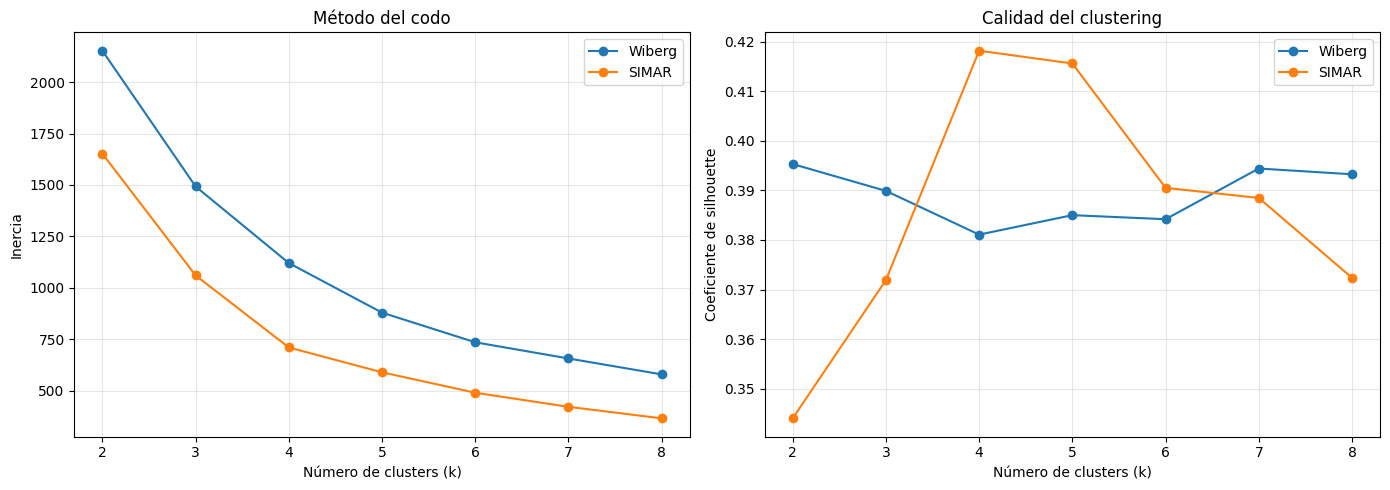

In [ ]:
# ============================================================
# FIGURA: Método del codo + Silhouette
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, df_k in resultados_k.items():
    axes[0].plot(df_k["k"], df_k["inertia"], marker="o", label=nombre)
    axes[1].plot(df_k["k"], df_k["silhouette"], marker="o", label=nombre)

axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Coeficiente de silhouette")
axes[1].set_title("Calidad del clustering")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# CLASIFICACIÓN DEFINITIVA

Se aplica K-Means con la combinación seleccionada (escenario Wiberg, k según config.xlsx).
Se clasifica también con SIMAR para poder hacer la comparación entre clasificaciones.

In [24]:
# Aplicar K-Means con k_final a cada escenario
if k_final == 2:
    nombres_clase = {0: "poco_oleaje", 1: "mucho_oleaje"}
else:
    nombres_clase = {i: f"clase_{i}" for i in range(k_final)}

for nombre, esc in escenarios.items():
    X_scaled = X_scaled_dict[nombre]
    col_oleaje = esc["col_oleaje"]

    kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
    labels_raw = kmeans.fit_predict(X_scaled)

    # Reordenar clusters por oleaje medio ascendente
    df_tmp = df[[col_oleaje]].copy()
    df_tmp["label"] = labels_raw
    orden = df_tmp.groupby("label")[col_oleaje].mean().sort_values().index.tolist()
    mapa = {orig: nuevo for nuevo, orig in enumerate(orden)}
    labels_sorted = np.array([mapa[l] for l in labels_raw])

    # Guardar en columnas separadas
    col_clase = f"oleaje_clase_{nombre}"
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    df[col_clase] = labels_sorted
    df[col_nombre_clase] = df[col_clase].map(nombres_clase)

    sil = silhouette_score(X_scaled, labels_sorted)
    print(f"\n=== {nombre} (k={k_final}) ===")
    print(f"  Silhouette: {sil:.4f}")
    print(f"  Distribución: {dict(pd.Series(labels_sorted).value_counts().sort_index())}")


=== Wiberg (k=4) ===
  Silhouette: 0.3811
  Distribución: {0: np.int64(137), 1: np.int64(169), 2: np.int64(190), 3: np.int64(164)}

=== SIMAR (k=4) ===
  Silhouette: 0.4182
  Distribución: {0: np.int64(121), 1: np.int64(145), 2: np.int64(212), 3: np.int64(182)}


In [25]:
# Resumen por clase para cada escenario
for nombre, esc in escenarios.items():
    col_clase = f"oleaje_clase_{nombre}"
    col_nombre_clase = f"oleaje_clase_{nombre}_nombre"
    print(f"\n{'='*60}")
    print(f"RESUMEN — {nombre}")
    print(f"{'='*60}")
    display(
        df.groupby([col_clase, col_nombre_clase])[esc["features"]]
        .agg(["count", "mean", "std", "median"])
        .round(4)
    )


RESUMEN — Wiberg


Oleaje                   \
                                                count     mean     std   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   clase_0                       130  12.0336  3.6017   
1                   clase_1                       154  13.4959  4.3843   
2                   clase_2                       148  27.0294  5.3336   
3                   clase_3                       118  30.0248  4.5028   

                                                       Mod_orbital          \
                                                median       count    mean   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                               
0                   clase_0                     10.102         137  0.0196   
1                   clase_1                     11.674         169  0.0226   
2                   clase_2                     26.046         190  0.0506   
3                   clase_3                     29.744         164  0.0558   

                                                               STD_orbital  \
                                                   std  median       count   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                               
0                   clase_0                     0.0076  0.0156         137   
1                   clase_1                     0.0090  0.0195         169   
2                   clase_2                     0.0104  0.0478         190   
3                   clase_3                     0.0095  0.0543         164   

                                                        ... pres__mean  \
                                                  mean  ...        std   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre          ...              
0                   clase_0                     0.0127  ...    36.4103   
1                   clase_1                     0.0149  ...    39.3604   
2                   clase_2                     0.0332  ...    28.0577   
3                   clase_3                     0.0379  ...    31.5059   

                                                           \
                                                   median   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre              
0                   clase_0                     1611.9759   
1                   clase_1                     1475.9661   
2                   clase_2                     1590.2447   
3                   clase_3                     1487.9527   

                                               pres__standard_deviation  \
                                                                  count   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                            
0                   clase_0                                         137   
1                   clase_1                                         169   
2                   clase_2                                         190   
3                   clase_3                                         164   

                                                                        \
                                                  mean     std  median   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   clase_0                     4.2373  0.9663  4.3771   
1                   clase_1                     4.4886  1.0720  4.6561   
2                   clase_2                     7.3480  1.3030  7.0355   
3                   clase_3                     7.9846  1.1859  7.8714   

                                               pres__median             \
                                                      count       mean   
oleaje_clase_Wiberg oleaje_clase_Wiberg_nombre                           
0                   clase_0                             137  1612.0993   
1                   clase_1                             169  1471.4683   
2                   clase_2                             190  1587.8359  


RESUMEN — SIMAR


Oleaje_SIMAR                  \
                                                    count    mean     std   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  clase_0                            121  1.8459  0.3905   
1                  clase_1                            145  2.1865  0.7806   
2                  clase_2                            212  4.2371  0.6420   
3                  clase_3                            182  4.2764  0.5005   

                                                    pres__mean             \
                                             median      count       mean   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  clase_0                    1.860        121  1610.9546   
1                  clase_1                    1.850        145  1470.2540   
2                  clase_2                    4.225        212  1589.5981   
3                  clase_3                    4.310        182  1484.9817   

                                                                  \
                                                  std     median   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                       
0                  clase_0                    37.7391  1607.4591   
1                  clase_1                    39.9798  1477.8663   
2                  clase_2                    28.6813  1591.0763   
3                  clase_3                    29.6560  1486.4802   

                                             pres__standard_deviation          \
                                                                count    mean   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                    
0                  clase_0                                        121  4.1219   
1                  clase_1                                        145  4.2716   
2                  clase_2                                        212  7.2603   
3                  clase_3                                        182  7.6230   

                                                             pres__median  \
                                                 std  median        count   
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                                
0                  clase_0                    0.9537  4.3085          121   
1                  clase_1                    0.9837  4.3628          145   
2                  clase_2                    1.4764  6.9907          212   
3                  clase_3                    1.2626  7.6285          182   

                                                                           
                                                   mean      std   median  
oleaje_clase_SIMAR oleaje_clase_SIMAR_nombre                               
0                  clase_0                    1610.9810  37.6955  1607.70  
1                  clase_1                    1470.2219  39.9971  1477.65  
2                  clase_2                    1589.6305  28.6762  1591.15  
3                  clase_3                    1485.0132  29.6830  1486.75

# COMPARACIÓN ENTRE CLASIFICACIONES Y COMPROBACIONES

In [ ]:
# ============================================================
# CONCORDANCIA: tabla de contingencia entre clasificaciones
# ============================================================

if "oleaje_clase_Wiberg" in df.columns and "oleaje_clase_SIMAR" in df.columns:
    tabla_contingencia = pd.crosstab(
        df["oleaje_clase_Wiberg_nombre"],
        df["oleaje_clase_SIMAR_nombre"],
        rownames=["Wiberg"],
        colnames=["SIMAR"],
    )
    display(tabla_contingencia)

    concordancia = (df["oleaje_clase_Wiberg"] == df["oleaje_clase_SIMAR"]).mean() * 100
    print(f"\nConcordancia: {concordancia:.1f}% de ventanas clasificadas igual")
else:
    print("Faltan columnas de clasificación.")

SIMAR,clase_0,clase_1,clase_2,clase_3
Wiberg,,,,
clase_0,120,0,17,0
clase_1,1,143,3,22
clase_2,0,1,184,5
clase_3,0,1,8,155



Concordancia: 91.2% de ventanas clasificadas igual


# CREACIÓN DE FICHEROS CON LOS DATOS CLASIFICADOS

In [27]:
# Columnas de clasificación generadas
cols_clase = [c for c in df.columns if c.startswith("oleaje_clase_")]
print("Columnas de clasificación guardadas:")
print(cols_clase)

output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_classified.csv")
df.to_csv(output_path, index=False)
print(f"\nDatos guardados en: {output_path}")

Columnas de clasificación guardadas:
['oleaje_clase_Wiberg', 'oleaje_clase_Wiberg_nombre', 'oleaje_clase_SIMAR', 'oleaje_clase_SIMAR_nombre']

Datos guardados en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\TFM_OxygenFlux\Pipeline\DATA\PROCESSED\df_classified.csv
